plot_PCA notebook
- Generates PCA visualizations of compositional search space in two dimensions, allowing analysis of compositional variation in FALCON generated LNPs 
- Ensure the <u>R kernel (falcon-env)</u> is selected.
- Run configuration and PCA computation before proceeding to plotting
- Note: This script requires composition datasets of LNP formulations

In [1]:
### Required Run Parameters ### 

#Name of the csv file, used to extract composition data
# DATASET_NAME = 'Normalized_RAMOS_Single_Objective_3ITER_DSPC_DlinMC3CMA'  # fig 2 composition dataset 
# DATASET_NAME = 'Fig3_PCA_Convergence_Compositions' # fig 3 composition dataset 
DATASET_NAME = 'PCA_RAMOS_HEGP2_FALCON_Dataset'  # SI Fig 1 PCA dataset
# DATASET_NAME = 'Normalized_RAMOS_C2C12_DC24_3T3_Quad_Objective_3ITER_18PG_SM102'  # SI Fig 13 composition dataset

RUN_NAME = "RAMOS_HEPG2_PCA" #for saving generated plots
cell_type = 'Diff' # only needed if you want to shade by LnRLU
#cell_type = 'Selectivity' # only needed if you want to shade by LnRLU

### Configuration ###

In [2]:
library(ggplot2)

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang


In [3]:
# Updated custom theme
custom_theme <- theme(
  plot.background = element_rect(fill = "transparent", colour = NA),  # Plot background
  panel.background = element_rect(fill = "transparent", colour = NA),  # Main panel
  plot.title = element_text(size = 35, hjust = 0.5, face = "plain", colour = "black"), 
  axis.text.y = element_text(size = 30, face = "plain", colour = "black"),  
  axis.text.x = element_text(size = 30, face = "plain", colour = "black"), 
  axis.title.x = element_text(size = 35, face = "plain", colour = "black"),  
  axis.title.y = element_text(size = 35, face = "plain", colour = "black"), 
  axis.line.x.bottom = element_line(color = "black", size = 1),  # Thicker black x-axis line
  axis.line.y.left = element_line(color = "black", size = 1),    # Thicker black y-axis line
  axis.ticks.length = unit(0.4, "cm"),  # Bigger tick marks
  axis.ticks = element_line(color = "black", size = 1.5),  # Thicker black tick marks
  legend.background = element_blank(),
  legend.key = element_blank(),
  panel.grid.major = element_blank(),
  panel.grid.minor = element_blank(),
  legend.text = element_text(size = 22),  
  legend.title = element_text(size = 22),  
  legend.key.size = unit(3, "lines")
)

In [5]:
#check if RUN_NAME exists, if not create it
output_path <- file.path("..", "/output/", RUN_NAME)
if (!dir.exists(output_path)) {
  dir.create(output_path)
}

### PCA Computation ###

In [6]:
# import data 
data <- read.csv(paste0("../datasets/", DATASET_NAME, ".csv"))
head(data)

ï..Formula_label,FALCON_ID,Iter,Opt_Method,Max_Cell_Target,Ionizable_Lipid,Helper_lipid,NP_ratio,X.IL.HL.,HL_.IL.HL.,PEG_.Chol.PEG.,LnLE_RAMOS,LnLE_HEPG2,LnLE_Selectivity,nLogRLU_Diff,Formula_label
1,F1001,0,N/A,N/A,SM-102,18PG,10,77.8,42.9,5,0.6295302,1.38255966,-0.7530294,-0.3270365,1
2,F1002,0,N/A,N/A,SM-102,18PG,7,77.8,42.9,5,0.7814713,1.75515118,-0.9736799,-0.4228638,2
3,F1003,0,N/A,N/A,SM-102,18PG,4,77.8,42.9,5,0.6574294,0.12759827,0.5298311,0.2301027,3
4,F1004,0,N/A,N/A,SM-102,18PG,10,77.8,42.9,1,0.7013499,0.01766689,0.6836830,0.2969198,4
5,F1005,0,N/A,N/A,SM-102,18PG,7,77.8,42.9,1,0.6569835,1.59243963,-0.9354562,-0.4062635,5
6,F1006,0,N/A,N/A,SM-102,18PG,4,77.8,42.9,1,0.6540331,1.68124294,-1.0272098,-0.4461116,6


In [7]:
# Run PCA on the dataset, keeping only the first two principal components
selected_cols <- c("NP_ratio", "HL_.IL.HL.", "X.IL.HL.", "PEG_.Chol.PEG.")

pca <- prcomp(data[, selected_cols], center = TRUE, scale. = TRUE)
summary(pca) # Summarizes importance of the principal components

# Extract the principal components
pca_data <- data.frame(pca$x)

# Combine with the species data for plotting
pca_data$Iter <- data$Iter
pca_data$Opt_Method <- data$Opt_Method
RLU_col <- paste0("nLogRLU_", cell_type)
pca_data$RLU <- data[[RLU_col]]
pca_data$Cell_Target <- data$Cell_Target
pca_data$Formula_label <- data$Formula_label

print(head(pca_data))

Importance of components:
                          PC1    PC2    PC3    PC4
Standard deviation     1.1607 0.9807 0.9476 0.8905
Proportion of Variance 0.3368 0.2404 0.2245 0.1983
Cumulative Proportion  0.3368 0.5773 0.8017 1.0000

          PC1        PC2       PC3        PC4 Iter Opt_Method        RLU
1 -0.90500213  2.1914241 0.6594672 -0.9290667    0        N/A -0.3270365
2 -0.49547005  1.7989713 1.1823167 -1.2728161    0        N/A -0.4228638
3 -0.08593797  1.4065185 1.7051663 -1.6165655    0        N/A  0.2301027
4 -1.78618350  0.2385819 0.3749047 -0.1821767    0        N/A  0.2969198
5 -1.37665141 -0.1538709 0.8977543 -0.5259261    0        N/A -0.4062635
6 -0.96711933 -0.5463237 1.4206039 -0.8696755    0        N/A -0.4461116
  Formula_label
1             1
2             2
3             3
4             4
5             5
6             6


### Plotting ###

##### Fig 2 Plots (Examples) #####

Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windowsWarning message:
"Removed 1 rows containing missing values (geom_point)."Warning message:
"Removed 1 rows containing missing values (geom_point)."

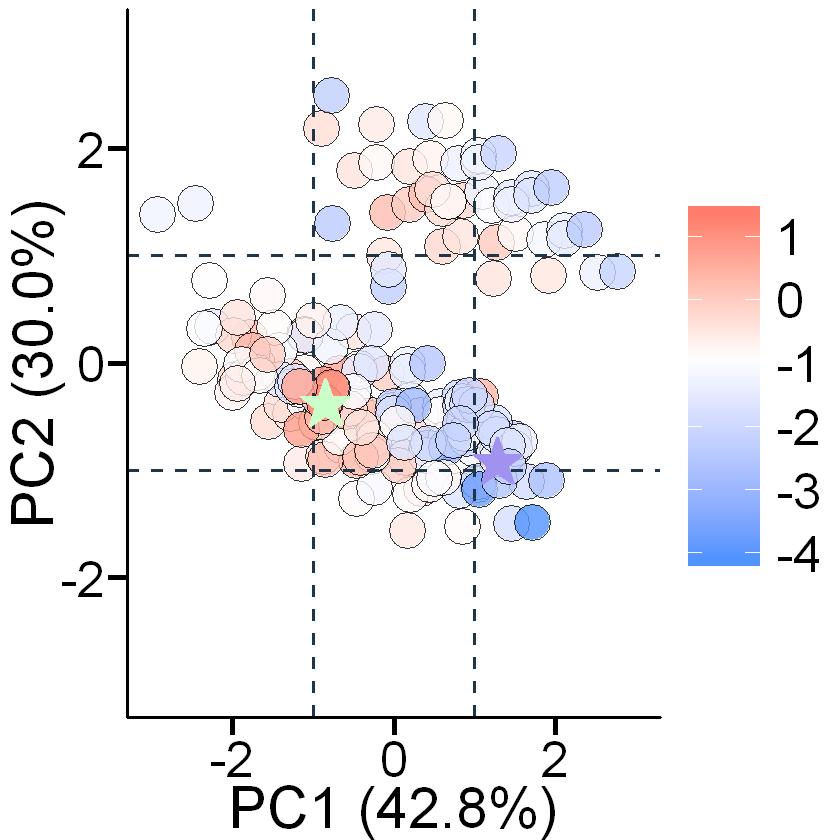

In [22]:
#Plot Grid

# Generate the plot with NSGAII data only
hist_data <- pca_data[pca_data$Opt_Method != 'i-optimal', ]
hist_data <- hist_data[hist_data$Opt_Method != 'i-optimal_minCT', ]

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#5193ff", mid = "#ffffff", high = "#ff3636", midpoint = median(hist_data$RLU)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis 
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  geom_text(
    data = subset(hist_data, Formula_label == 179),
    aes(x = PC1, y = PC2),
    label = "\u2605",   # ★
    color = "#CAFFCA", 
    size = 18,
    fontface = "bold"
  ) +
   geom_text(
    data = subset(hist_data, Formula_label == 119),
    aes(x = PC1, y = PC2),
    label = "\u2605",   # ★
    color = "#a292ef", 
    size = 18,
    fontface = "bold"
  ) +
  custom_theme + 
  labs(x = "PC1 (42.8%)",
       y = "PC2 (30.0%)", 
       fill = "") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 20), # Increase the size of the legend title
        )
# Display the plot

filename <- paste0("../output/", RUN_NAME, "/Fig2_Grid_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600, width = 8.5, height = 7)
print(p_pca)


Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windows

Warning message:
"Removed 1 rows containing missing values (geom_point)."Warning message:
"Removed 1 rows containing missing values (geom_point)."

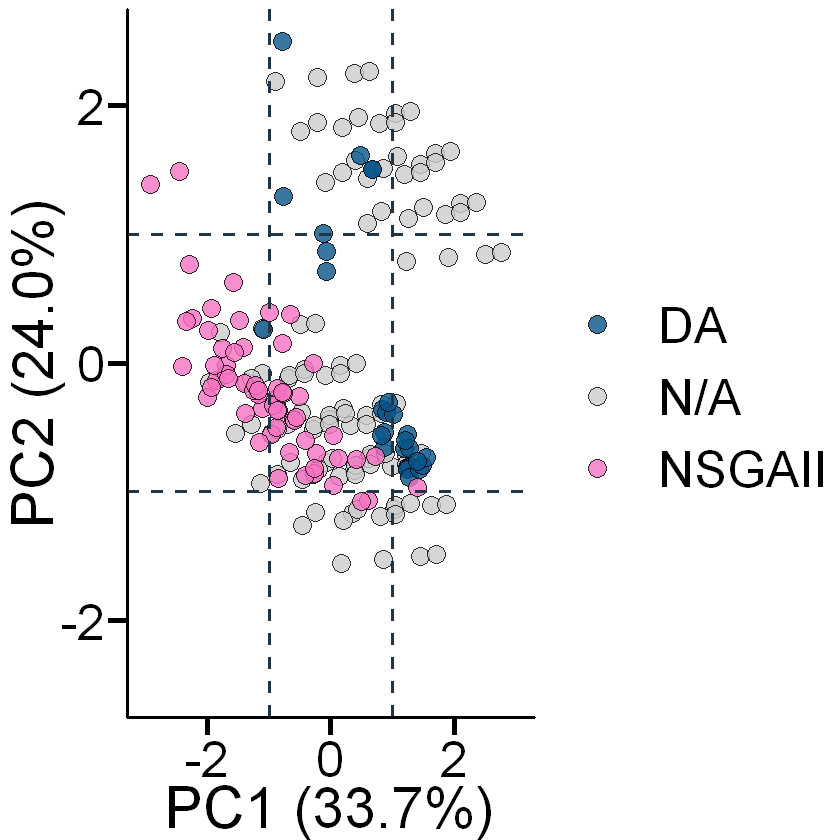

In [20]:
#Plot URS

# Generate the plot
custom_colors <- c("N/A" = "#cccccc", "DA" = "#07558a", "NSGAII" = "#f872c2")
hist_data <- pca_data

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 5) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
 labs(x = "PC1 (33.7%)",
       y = "PC2 (24.0%)", 
       fill = "") +
 # geom_text(
 #   data = subset(hist_data, Formula_label == 119),
 #   aes(x = PC1, y = PC3),
 #   label = "\u2605",   # ★
 #   color = "#a292ef", 
 #   size = 18,
 #   fontface = "bold"
 # ) +
 #   geom_text(
 #   data = subset(hist_data, Formula_label == 179),
 #   aes(x = PC1, y = PC3),
 #   label = "\u2605",   # ★
 #   color = "#CAFFCA", 
 #   size = 18,
 #   fontface = "bold"
 # ) +
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter1_PCA_Both.png")
ggsave(filename, plot = p_pca, width = 9, height = 6, dpi = 600)
print(p_pca)


Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windowsSaving 6.67 x 6.67 in image


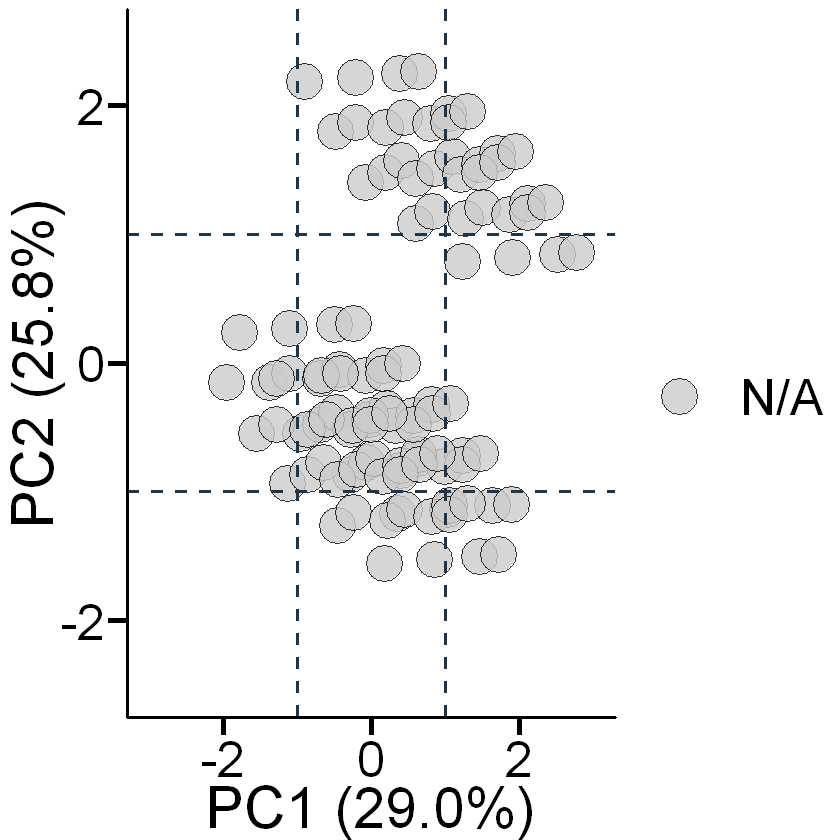

In [14]:
#Plot URS

# Generate the plot
custom_colors <- c("N/A" = "#cccccc", "DA" = "#07558a", "NSGAII" = "#f872c2")
hist_data <- subset(pca_data, Opt_Method == "N/A")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
 labs(x = "PC1 (29.0%)",
       y = "PC2 (25.8%)", 
       fill = "") +
 # geom_text(
 #   data = subset(hist_data, Formula_label == 119),
 #   aes(x = PC1, y = PC3),
 #   label = "\u2605",   # ★
 #   color = "#a292ef", 
 #   size = 18,
 #   fontface = "bold"
 # ) +
 #   geom_text(
 #   data = subset(hist_data, Formula_label == 179),
 #   aes(x = PC1, y = PC3),
 #   label = "\u2605",   # ★
 #   color = "#CAFFCA", 
 #   size = 18,
 #   fontface = "bold"
 # ) +
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter1_PCA_Both.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windowsSaving 6.67 x 6.67 in image
Warning message:
"Removed 2 rows containing missing values (geom_point)."Warning message:
"Removed 2 rows containing missing values (geom_point)."

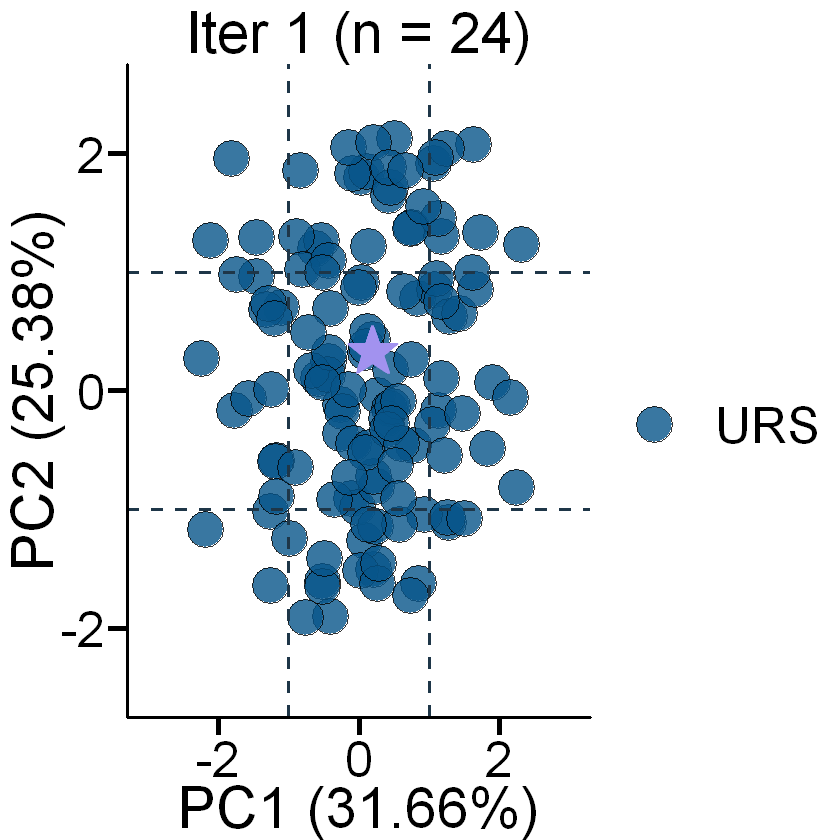

In [42]:
# exclude DA
#Plot URS

# Generate the plot
custom_colors <- c("URS" = "#07558a", "DA" = "#f872c2")
hist_data <- subset(pca_data, Opt_Method == "URS")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 1 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Changed from 'color' to 'fill'
  geom_text(
    data = subset(hist_data, Formula_label == 36),
    aes(x = PC1, y = PC2),
    label = "\u2605",   # ★
    color = "#a292ef", 
    size = 18,
    fontface = "bold"
  ) +
    geom_text(
    data = subset(hist_data, Formula_label == 150),
    aes(x = PC1, y = PC2),
    label = "\u2605",   # ★
    color = "#CAFFCA", 
    size = 18,
    fontface = "bold"
  ) +
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter1_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


In [ ]:
#Plot Iter1

# Generate the plot
custom_colors <- c("DA" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 1)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 1 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Changed from 'color' to 'fill'
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter1_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


ERROR: Error in eval(e, x, parent.frame()): object 'Iter' not found


Saving 6.67 x 6.67 in image
Warning message:
"Removed 4 rows containing missing values (geom_point)."Warning message:
"Removed 4 rows containing missing values (geom_point)."

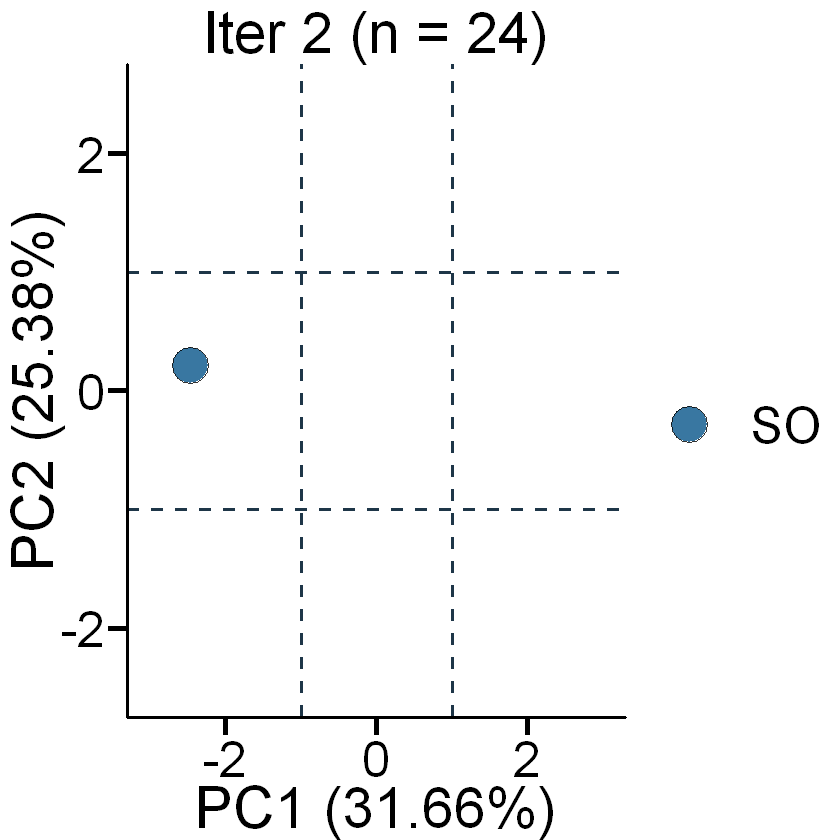

In [37]:
#Plot Iter2

# Generate the plot
custom_colors <- c("SO" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 2)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 2 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Change legend title to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter2_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Saving 6.67 x 6.67 in image


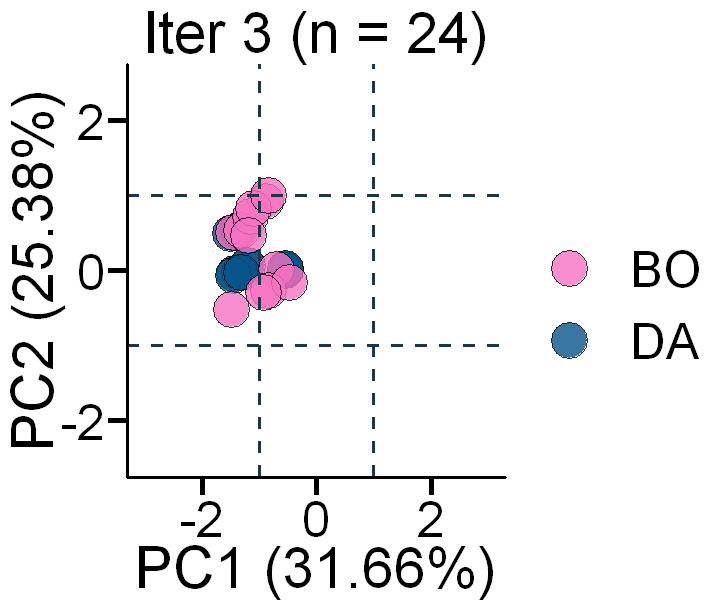

In [190]:
#Plot Iter3

# Generate the plot
custom_colors <- c("DA" = "#07558a", "BO" = "#f872c2")
hist_data <- subset(pca_data, Iter == 3)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Iter 3 (n = 24)",
       x = "PC1 (31.66%)",
       y = "PC2 (25.38%)",
       fill = "") +  # Update to match fill aesthetic
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Iter3_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windowsSaving 6.67 x 6.67 in image


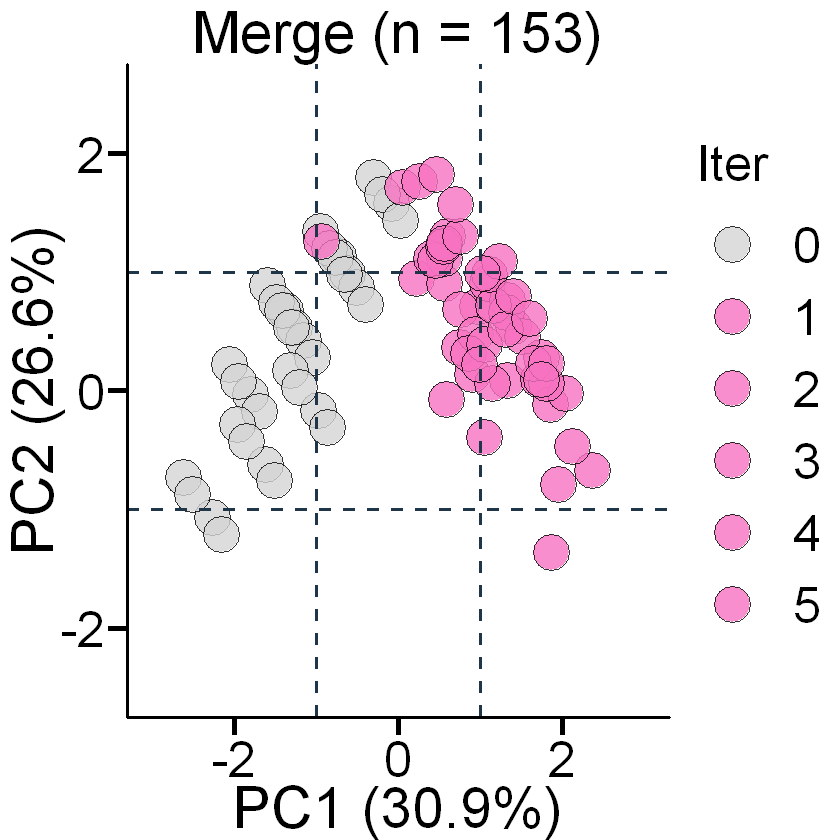

In [13]:
#exclude rows with Opt_Method == 'i-optimal' 
filtered_pca_data <- pca_data[pca_data$Opt_Method != 'i-optimal', ]
#exclude rows with Opt_Method == 'i-optimal_minCT'
filtered_pca_data <- filtered_pca_data[filtered_pca_data$Opt_Method != 'i-optimal_minCT', ]

#Plot Merge
custom_colors <- c("0" = "#d4d4d4", "1" = "#f872c2", "2" = "#f872c2", "3" = "#f872c2", "4" = "#f872c2","5" = "#f872c2")

p_pca <- ggplot(filtered_pca_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
    geom_text(
    data = subset(hist_data, Formula_label == 162),
    aes(x = PC1, y = PC2),
    label = "\u2605",   # ★
    color = "#CAFFCA", 
    size = 18,
    fontface = "bold"
  ) +
  custom_theme + 
  labs(title = "Merge (n = 153)",
       x = "PC1 (30.9%)",
       y = "PC2 (26.6%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 30),
    legend.title = element_text(size = 30)
  )

filename <- paste0("../output/", RUN_NAME, "/Fig2_Merge_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


##### SI Fig 1 Plots (Examples) #####

Saving 6.67 x 6.67 in image


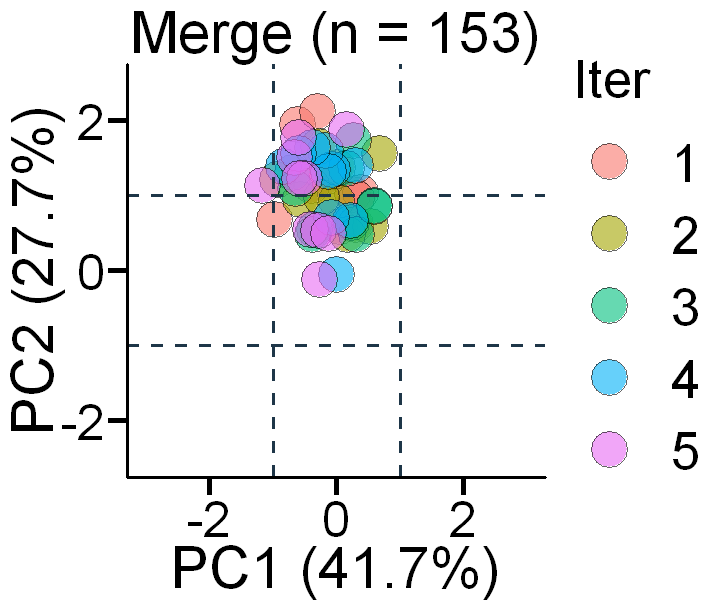

In [221]:
#Plot Merge for RAMOS

#exclude iter 0
hist_data <- subset(pca_data, Cell_Target == "RAMOS")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.6, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  #scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Merge (n = 153)",
       x = "PC1 (41.7%)",
       y = "PC2 (27.7%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 32),
    legend.title = element_text(size = 32)
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig1_RAMOS_Acquisition.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Saving 6.67 x 6.67 in image


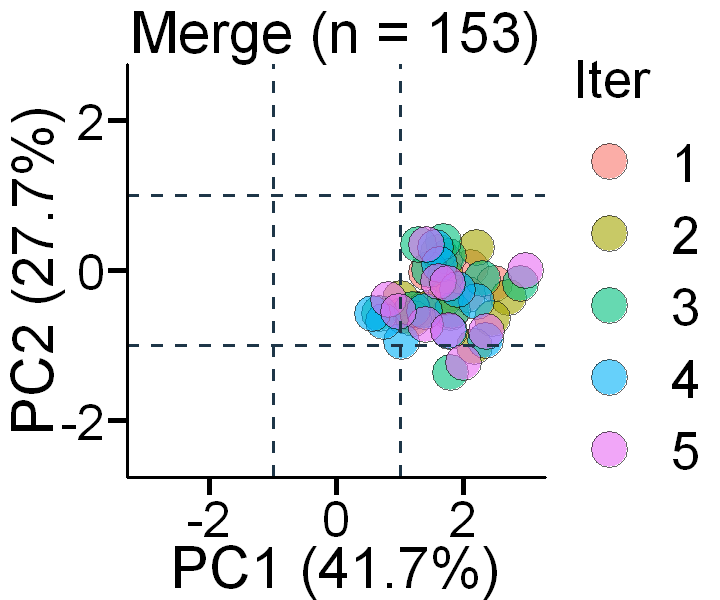

In [222]:
#Plot Merge for THP

#exclude iter 0
hist_data <- subset(pca_data, Cell_Target == "THP1")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.6, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Custom fill color scale
  #scale_fill_manual(values = custom_colors) +
  # Axis configuration
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "Merge (n = 153)",
       x = "PC1 (41.7%)",
       y = "PC2 (27.7%)",
       fill = "Iter") +  # Update legend label to match fill
  theme(
    legend.position = "right",
    legend.text = element_text(size = 32),
    legend.title = element_text(size = 32)
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig1_THP1_Acquisition.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


##### SI Fig 13 Plot (Example) #####

Warning message:
"Removed 5 rows containing missing values (geom_point)."

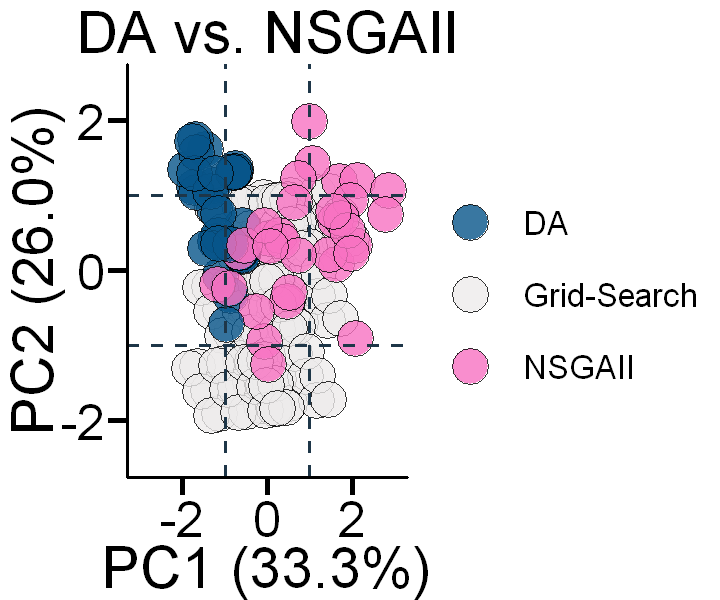

In [158]:
#Plot the DA vs. NSGA-II

# Generate the plot
custom_colors <- c("Grid-Search" = "#edebeb","DA" = "#07558a", "NSGAII" = "#f872c2")
hist_data <- subset(pca_data)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Opt_Method))) +
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Black border
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom fill color scale
  scale_fill_manual(values = custom_colors) +
  # Axis settings
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "DA vs. NSGAII",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)",
       fill = "") +  # Update to match fill aesthetic
  theme(
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 20),
  )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_AlgoComp.png")
# ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)


Warning message:
"Removed 2 rows containing missing values (geom_point)."

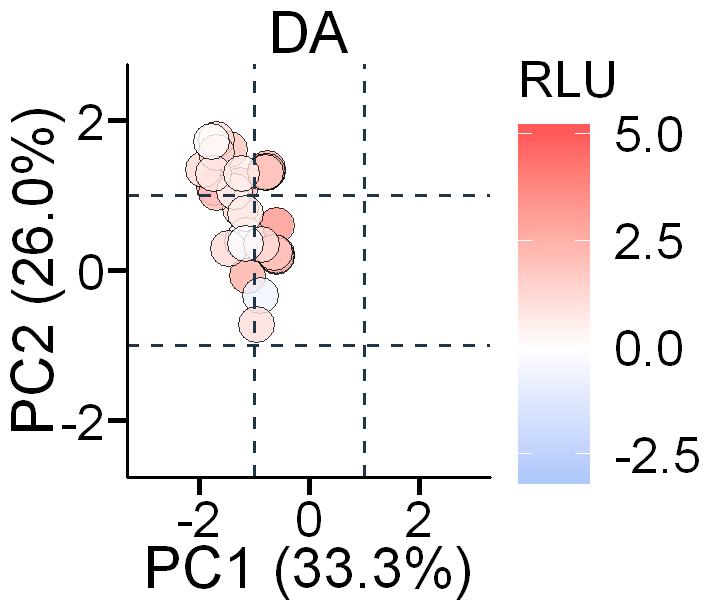

In [156]:
#Plot DA

# Generate the plot
hist_data <- subset(pca_data, Opt_Method == 'DA')
rlu_mid = 0
rlu_min = -3
rlu_max = 5

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#72a5f8", mid = "#ffffff", high = "#ff5959", midpoint = rlu_mid, limits = c(rlu_min, rlu_max)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "DA",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 30), # Increase the size of the legend title
        )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_DA.png")
# ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)



Warning message:
"Removed 3 rows containing missing values (geom_point)."

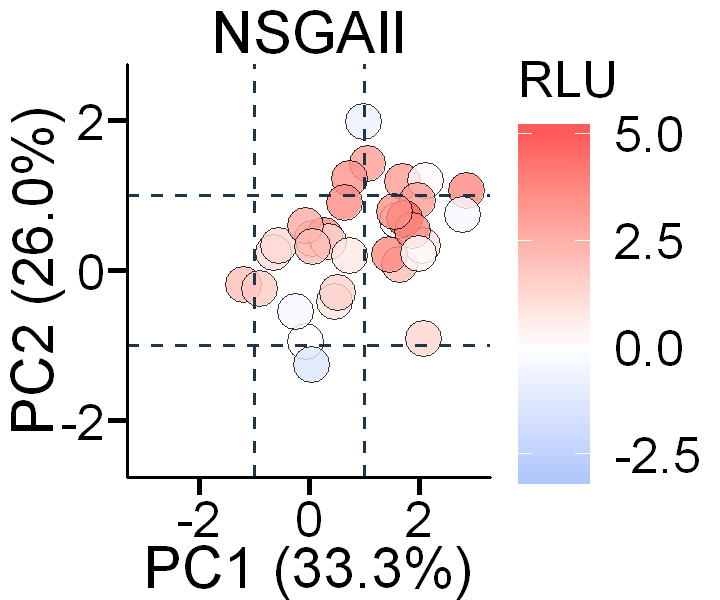

In [155]:
#Plot NSGAII

# Generate the plot
hist_data <- subset(pca_data, Opt_Method == 'NSGAII')
rlu_mid = 0
rlu_min = -3
rlu_max = 5

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = RLU)) +  # Use fill instead of color for shape 21
  geom_point(shape = 21, color = "black", stroke = 0.5, alpha = 0.8, size = 10) +  # Add black border with stroke
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply a continuous fill scale instead of color
  scale_fill_gradient2(low = "#72a5f8", mid = "#ffffff", high = "#ff5959", midpoint = rlu_mid, limits = c(rlu_min, rlu_max)) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-2, 0, 2), limits = c(-3, 3)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-2, 0, 2), limits = c(-2.5, 2.5)) +
  custom_theme +
  labs(title = "NSGAII",
       x = "PC1 (33.3%)",
       y = "PC2 (26.0%)") +
  theme(legend.position = "right",
        legend.text = element_text(size = 30),  # Increase the size of the legend labels
        legend.title = element_text(size = 30), # Increase the size of the legend title
        )

filename <- paste0("../output/", RUN_NAME, "/SI_Fig13_NSGAII.png")
# ggsave(filename, plot = p_pca, width = 9, height = 7, dpi = 600)
print(p_pca)



##### Fig 3 Plots (Examples) #####

Saving 6.67 x 6.67 in image
Warning message:
"Removed 15 rows containing missing values (geom_point)."Warning message:
"Removed 15 rows containing missing values (geom_point)."

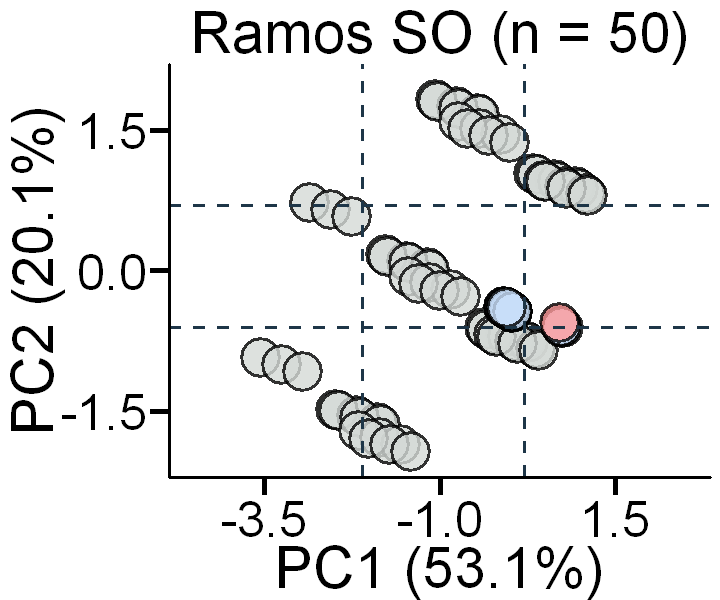

In [210]:
#Plot Ramos SO

# Generate the plot
custom_colors <- c("0" = "#d4d9d6", "Top" = "#ff9999", "3" = "#C8DEF9")
hist_data <- subset(pca_data, (Opt_Method == "DA" & Cell_Target == 'RAMOS') | Iter == 0)

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1.5, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-0.6, 0.7), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-1.5, 0, 1.5), limits = c(-2, 2)) +
  custom_theme +
  labs(title = "Ramos SO (n = 50)",
       x = "PC1 (53.1%)",
       y = "PC2 (20.1%)") +
  theme(legend.position = "none")

filename <- paste0("../output/", RUN_NAME, "/Fig3_RAMOS_DA_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)


Saving 6.67 x 6.67 in image
Warning message:
"Removed 15 rows containing missing values (geom_point)."Warning message:
"Removed 15 rows containing missing values (geom_point)."

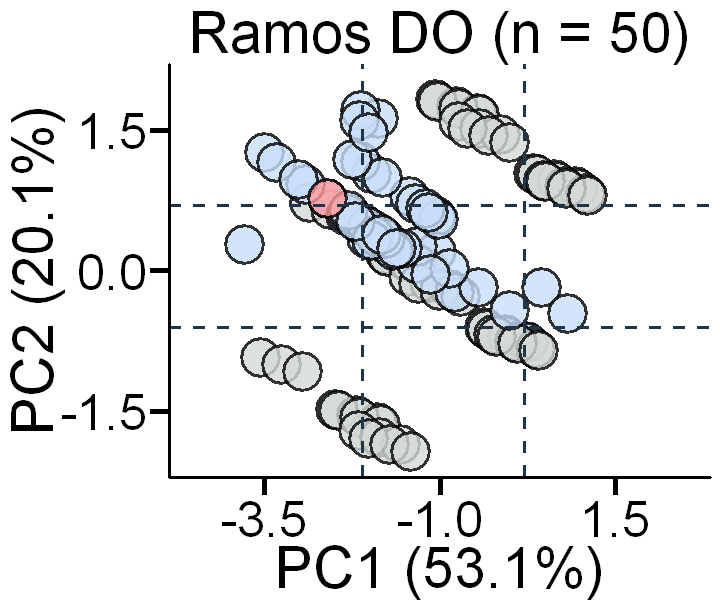

In [211]:
#Plot Ramos DO

# Generate the plot
hist_data <- subset(pca_data, (Opt_Method == "NSGAII" & Cell_Target == 'RAMOS') | Iter == 0)
custom_colors <- c("0" = "#d4d9d6", "Top" = "#ff9999", "3" = "#C8DEF9")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1.5, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-0.6, 0.7), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-1.5, 0, 1.5), limits = c(-2, 2)) +
  custom_theme +
  labs(title = "Ramos DO (n = 50)",
       x = "PC1 (53.1%)",
       y = "PC2 (20.1%)") + theme(legend.position = "none")

filename <- paste0("../output/", RUN_NAME, "/Fig3_RAMOS_NSGAII_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)

Saving 6.67 x 6.67 in image
Warning message:
"Removed 15 rows containing missing values (geom_point)."Warning message:
"Removed 15 rows containing missing values (geom_point)."

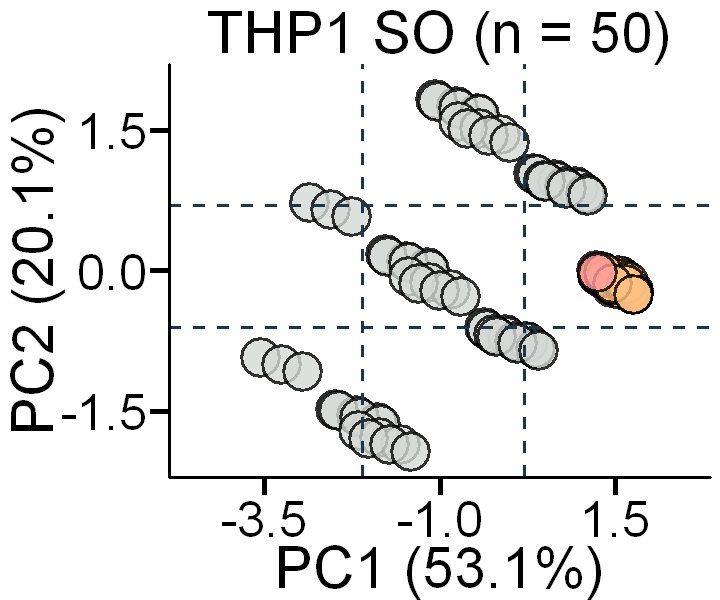

In [212]:
#Plot THP1 SO

# Generate the plot
hist_data <- subset(pca_data, (Opt_Method == "DA" & Cell_Target == 'THP1') | Iter == 0)
custom_colors <- c("0" = "#d4d9d6", "Top" = "#ff9999", "3" = "#FFC080")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1.5, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-0.6, 0.7), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-1.5, 0, 1.5), limits = c(-2, 2)) +
  custom_theme +
  labs(title = "THP1 SO (n = 50)",
       x = "PC1 (53.1%)",
       y = "PC2 (20.1%)") + theme(legend.position = "none")

filename <- paste0("../output/", RUN_NAME, "/Fig3_THP1_DA_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)

Saving 6.67 x 6.67 in image
Warning message:
"Removed 15 rows containing missing values (geom_point)."Warning message:
"Removed 15 rows containing missing values (geom_point)."

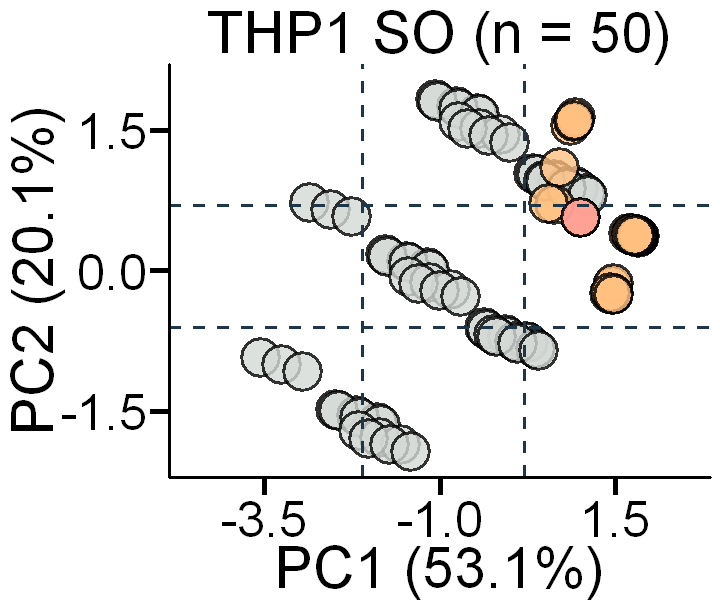

In [213]:
#Plot THP1 SO

# Generate the plot
hist_data <- subset(pca_data, (Opt_Method == "NSGAII" & Cell_Target == 'THP1') | Iter == 0)
custom_colors <- c("0" = "#d4d9d6", "Top" = "#ff9999", "3" = "#FFC080")

p_pca <- ggplot(hist_data, aes(x = PC1, y = PC2, fill = as.factor(Iter))) +
  geom_point(shape = 21, size = 10, color = "black", stroke = 1.5, alpha = 0.8) +  # Black outline added
  # Adding horizontal dashed lines
  geom_hline(yintercept = c(-0.6, 0.7), linetype = "dashed", color = "#1e3648", size = 1) +
  # Adding vertical dashed lines
  geom_vline(xintercept = c(-2.1, 0.2), linetype = "dashed", color = "#1e3648", size = 1) +
  # Apply the custom color scale for the fill
  scale_fill_manual(values = custom_colors) +
  # Use scale_x_continuous to set both breaks and limits for the x-axis
  scale_x_continuous(breaks = c(-3.5, -1, 1.5), limits = c(-4.5, 2.5)) +
  # Use scale_y_continuous to set both breaks and limits for the y-axis
  scale_y_continuous(breaks = c(-1.5, 0, 1.5), limits = c(-2, 2)) +
  custom_theme +
  labs(title = "THP1 SO (n = 50)",
       x = "PC1 (53.1%)",
       y = "PC2 (20.1%)") + theme(legend.position = "none")

filename <- paste0("../output/", RUN_NAME, "/Fig3_THP1_NSGAII_PCA.png")
ggsave(filename, plot = p_pca, dpi = 600)
print(p_pca)